# ⚡️ Energy-Based Models

In this notebook, we'll walk through the steps required to train your own Energy Based Model to predict the distribution of a demo dataset

The code is adapted from the excellent ['Deep Energy-Based Generative Models' tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial8/Deep_Energy_Models.html) created by Phillip Lippe.

In [27]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


In [28]:
# %load_ext autoreload
# %autoreload 2

import numpy as np

import tensorflow as tf
from tensorflow.keras import (
    datasets,
    layers,
    models,
    optimizers,
    activations,
    metrics,
    callbacks,
)

# from notebooks.utils import display, sample_batch
import random

In [29]:
import os
os.makedirs("./output", exist_ok=True)
os.makedirs("./logs", exist_ok=True)
os.makedirs("./models", exist_ok=True)

## 0. Parameters <a name="parameters"></a>

In [45]:
# IMAGE_SIZE = 32
# CHANNELS = 1
# STEP_SIZE = 10
# STEPS = 60
# NOISE = 0.005
# ALPHA = 0.1
# GRADIENT_CLIP = 0.03
# BATCH_SIZE = 128
# BUFFER_SIZE = 8192
# LEARNING_RATE = 0.0001
# EPOCHS = 60
# # EPOCHS = 10
# LOAD_MODEL = False


# Alt 2 to try an improve performance e.g. 1epoch was 12m!
# Reduce these parameters
STEP_SIZE = 10
STEPS = 20        # Try reducing to 20-30
NOISE = 0.005
ALPHA = 0.1
GRADIENT_CLIP = 0.03
BATCH_SIZE = 128
BUFFER_SIZE = 2048  # Try reducing to 2048-4096
LEARNING_RATE = 0.0001
EPOCHS = 10
LOAD_MODEL = False

In [31]:
# Load the data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

In [32]:
# Preprocess the data


def preprocess(imgs):
    """
    Normalize and reshape the images
    """
    imgs = (imgs.astype("float32") - 127.5) / 127.5
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=-1.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs


x_train = preprocess(x_train)
x_test = preprocess(x_test)

In [33]:
x_train = tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)
x_test = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE)

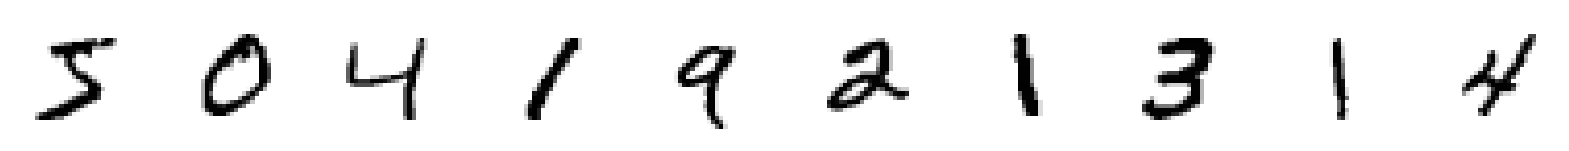

In [34]:
# Show some items of clothing from the training set
train_sample = sample_batch(x_train)
display(train_sample)

## 2. Build the EBM network <a name="train"></a>

In [35]:
ebm_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
x = layers.Conv2D(
    16, kernel_size=5, strides=2, padding="same", activation=activations.swish
)(ebm_input)
x = layers.Conv2D(
    32, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation=activations.swish)(x)
ebm_output = layers.Dense(1)(x)
model = models.Model(ebm_input, ebm_output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,993 (300.75 KB)

 Trainable params: 76,993 (300.75 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
if LOAD_MODEL:
    model.load_weights("./models/model.h5")

## 2. Set up a Langevin sampler function <a name="sampler"></a>

In [37]:
# Function to generate samples using Langevin Dynamics
def generate_samples(
    model, inp_imgs, steps, step_size, noise, return_img_per_step=False
):
    imgs_per_step = []
    for _ in range(steps):
        inp_imgs += tf.random.normal(inp_imgs.shape, mean=0, stddev=noise)
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        with tf.GradientTape() as tape:
            tape.watch(inp_imgs)
            out_score = model(inp_imgs)
        grads = tape.gradient(out_score, inp_imgs)
        grads = tf.clip_by_value(grads, -GRADIENT_CLIP, GRADIENT_CLIP)
        inp_imgs += step_size * grads
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        if return_img_per_step:
            imgs_per_step.append(inp_imgs)
    if return_img_per_step:
        return tf.stack(imgs_per_step, axis=0)
    else:
        return inp_imgs

## 3. Set up a buffer to store examples <a name="buffer"></a>

In [38]:
class Buffer:
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.examples = [
            tf.random.uniform(shape=(1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2
            - 1
            for _ in range(BATCH_SIZE)
        ]

    def sample_new_exmps(self, steps, step_size, noise):
        n_new = np.random.binomial(BATCH_SIZE, 0.05)
        rand_imgs = (
            tf.random.uniform((n_new, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
        )
        old_imgs = tf.concat(
            random.choices(self.examples, k=BATCH_SIZE - n_new), axis=0
        )
        inp_imgs = tf.concat([rand_imgs, old_imgs], axis=0)
        inp_imgs = generate_samples(
            self.model, inp_imgs, steps=steps, step_size=step_size, noise=noise
        )
        self.examples = tf.split(inp_imgs, BATCH_SIZE, axis=0) + self.examples
        self.examples = self.examples[:BUFFER_SIZE]
        return inp_imgs

In [39]:
class EBM(models.Model):
    def __init__(self):
        super(EBM, self).__init__()
        self.model = model
        self.buffer = Buffer(self.model)
        self.alpha = ALPHA
        self.loss_metric = metrics.Mean(name="loss")
        self.reg_loss_metric = metrics.Mean(name="reg")
        self.cdiv_loss_metric = metrics.Mean(name="cdiv")
        self.real_out_metric = metrics.Mean(name="real")
        self.fake_out_metric = metrics.Mean(name="fake")

    @property
    def metrics(self):
        return [
            self.loss_metric,
            self.reg_loss_metric,
            self.cdiv_loss_metric,
            self.real_out_metric,
            self.fake_out_metric,
        ]

    def train_step(self, real_imgs):
        real_imgs += tf.random.normal(
            shape=tf.shape(real_imgs), mean=0, stddev=NOISE
        )
        real_imgs = tf.clip_by_value(real_imgs, -1.0, 1.0)
        fake_imgs = self.buffer.sample_new_exmps(
            steps=STEPS, step_size=STEP_SIZE, noise=NOISE
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        with tf.GradientTape() as training_tape:
            real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
            cdiv_loss = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
                real_out, axis=0
            )
            reg_loss = self.alpha * tf.reduce_mean(
                real_out**2 + fake_out**2, axis=0
            )
            loss = cdiv_loss + reg_loss
        grads = training_tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(
            zip(grads, self.model.trainable_variables)
        )
        self.loss_metric.update_state(loss)
        self.reg_loss_metric.update_state(reg_loss)
        self.cdiv_loss_metric.update_state(cdiv_loss)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, real_imgs):
        batch_size = real_imgs.shape[0]
        fake_imgs = (
            tf.random.uniform((batch_size, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
            * 2
            - 1
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
        cdiv = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
            real_out, axis=0
        )
        self.cdiv_loss_metric.update_state(cdiv)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics[2:]}

In [40]:
ebm = EBM()

## 3. Train the EBM network <a name="train"></a>

In [41]:
# Compile and train the model
ebm.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), run_eagerly=True
)

In [42]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        start_imgs = (
            np.random.uniform(
                size=(self.num_img, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
            )
            * 2
            - 1
        )
        generated_images = generate_samples(
            ebm.model,
            start_imgs,
            steps=1000,
            step_size=STEP_SIZE,
            noise=NOISE,
            return_img_per_step=False,
        )
        generated_images = generated_images.numpy()
        display(
            generated_images,
            save_to="./output/generated_img_%03d.png" % (epoch),
        )

        example_images = tf.concat(
            random.choices(ebm.buffer.examples, k=10), axis=0
        )
        example_images = example_images.numpy()
        display(
            example_images, save_to="./output/example_img_%03d.png" % (epoch)
        )


image_generator_callback = ImageGenerator(num_img=10)

In [43]:
class SaveModel(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        model.save_weights("./models/model.weights.h5")


save_model_callback = SaveModel()

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - cdiv: -0.1519 - fake: 0.3685 - loss: -0.0975 - real: 0.5204 - reg: 0.0544
Saved to ./output/generated_img_000.png


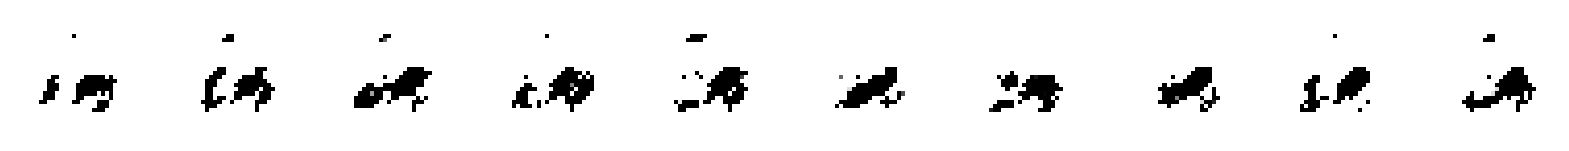


Saved to ./output/example_img_000.png


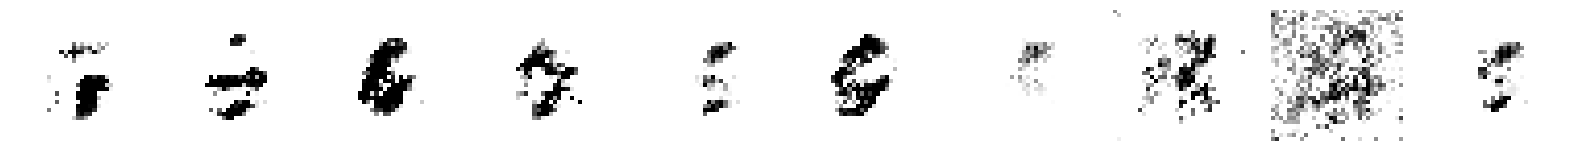

469/469 ━━━━━━━━━━━━━━━━━━━━ 314s 669ms/step - cdiv: -0.1324 - fake: 0.2662 - loss: -0.0917 - real: 0.3986 - reg: 0.0407 - val_cdiv: -2.8088 - val_fake: -2.8768 - val_real: -0.0680
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - cdiv: -0.0469 - fake: -0.0014 - loss: -0.0268 - real: 0.0454 - reg: 0.0200
Saved to ./output/generated_img_001.png


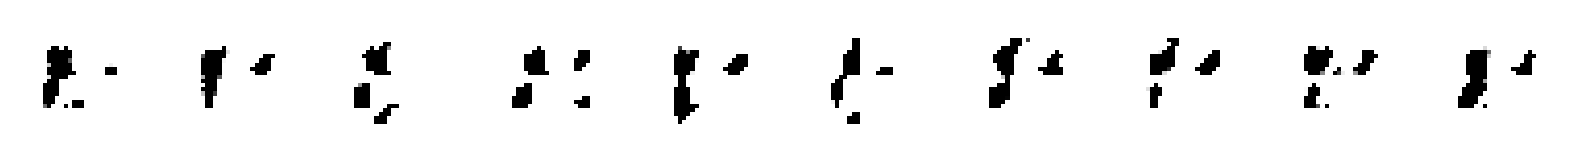


Saved to ./output/example_img_001.png


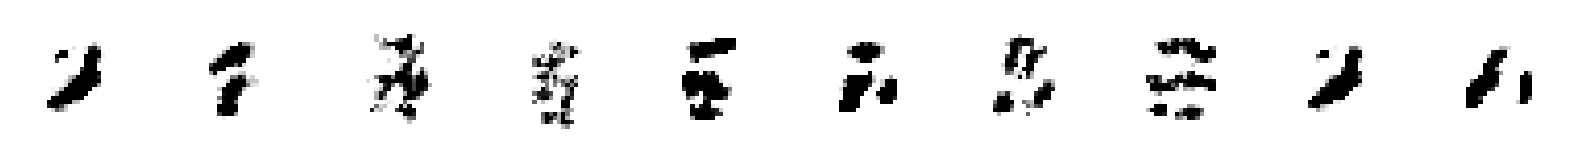

469/469 ━━━━━━━━━━━━━━━━━━━━ 319s 680ms/step - cdiv: -0.0359 - fake: -0.0013 - loss: -0.0193 - real: 0.0345 - reg: 0.0165 - val_cdiv: -5.1639 - val_fake: -5.1531 - val_real: 0.0108
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - cdiv: -0.0154 - fake: 0.0027 - loss: -0.0069 - real: 0.0182 - reg: 0.0085
Saved to ./output/generated_img_002.png


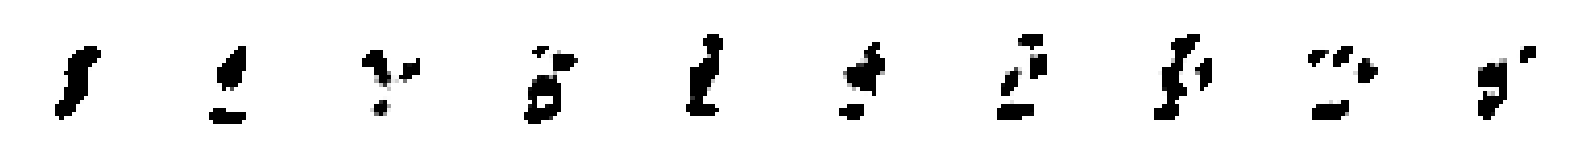


Saved to ./output/example_img_002.png


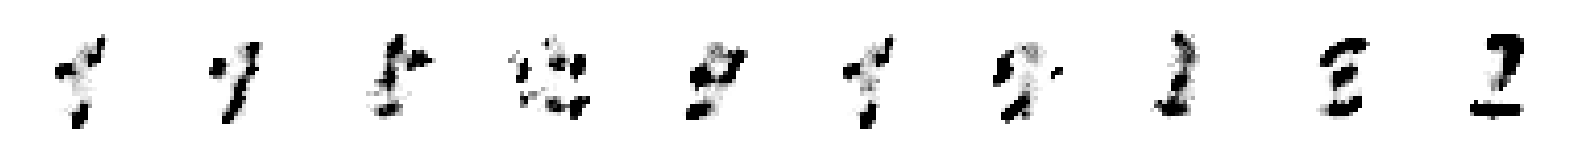

469/469 ━━━━━━━━━━━━━━━━━━━━ 315s 673ms/step - cdiv: -0.0080 - fake: 0.0045 - loss: -0.0017 - real: 0.0125 - reg: 0.0063 - val_cdiv: -6.6737 - val_fake: -6.6691 - val_real: 0.0045
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - cdiv: -0.0067 - fake: 0.0022 - loss: -0.0036 - real: 0.0089 - reg: 0.0031
Saved to ./output/generated_img_003.png


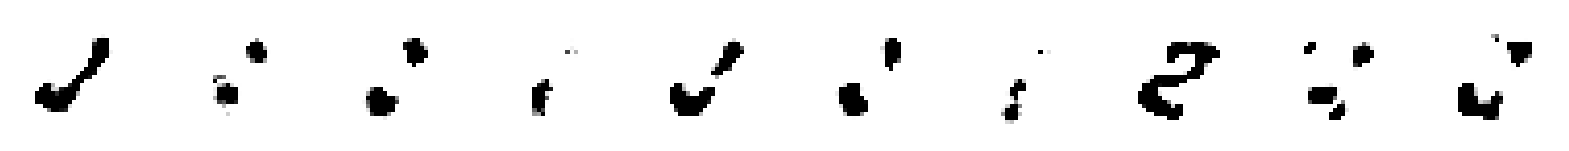


Saved to ./output/example_img_003.png


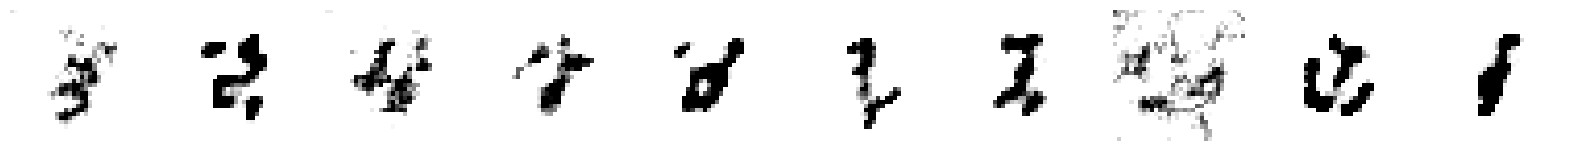

469/469 ━━━━━━━━━━━━━━━━━━━━ 319s 681ms/step - cdiv: -0.0057 - fake: 0.0021 - loss: -0.0031 - real: 0.0079 - reg: 0.0026 - val_cdiv: -8.8316 - val_fake: -8.7735 - val_real: 0.0581
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - cdiv: -0.0043 - fake: -0.0011 - loss: -0.0023 - real: 0.0032 - reg: 0.0020
Saved to ./output/generated_img_004.png


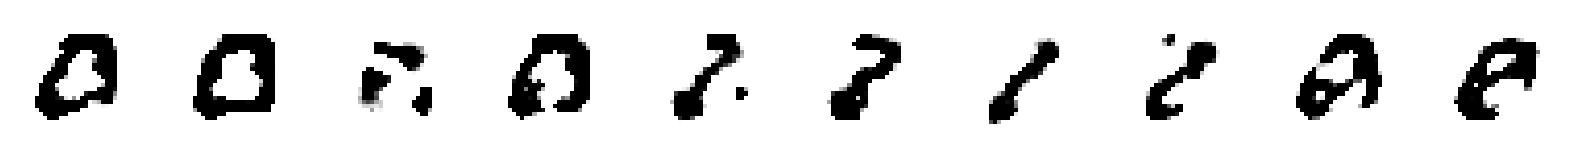


Saved to ./output/example_img_004.png


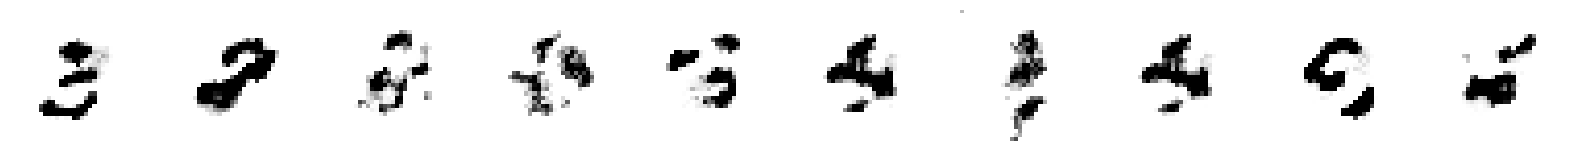

469/469 ━━━━━━━━━━━━━━━━━━━━ 316s 673ms/step - cdiv: -0.0035 - fake: -7.4631e-04 - loss: -0.0015 - real: 0.0027 - reg: 0.0019 - val_cdiv: -10.5749 - val_fake: -10.5925 - val_real: -0.0175
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - cdiv: -0.0053 - fake: -0.0032 - loss: -0.0031 - real: 0.0021 - reg: 0.0022
Saved to ./output/generated_img_005.png


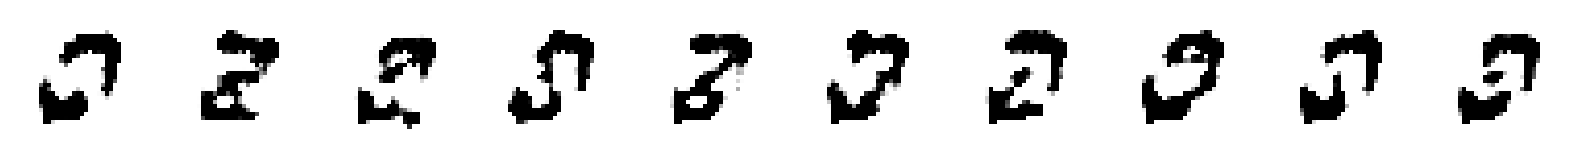


Saved to ./output/example_img_005.png


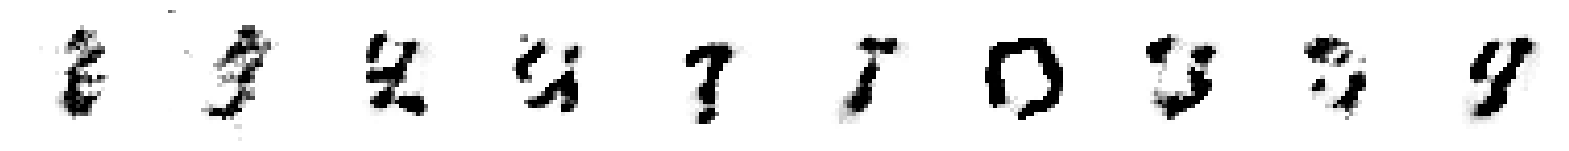

469/469 ━━━━━━━━━━━━━━━━━━━━ 315s 672ms/step - cdiv: -0.0018 - fake: 0.0022 - loss: -4.4385e-05 - real: 0.0040 - reg: 0.0018 - val_cdiv: -12.4841 - val_fake: -12.4326 - val_real: 0.0514
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - cdiv: -0.0042 - fake: -0.0090 - loss: -0.0026 - real: -0.0048 - reg: 0.0016
Saved to ./output/generated_img_006.png


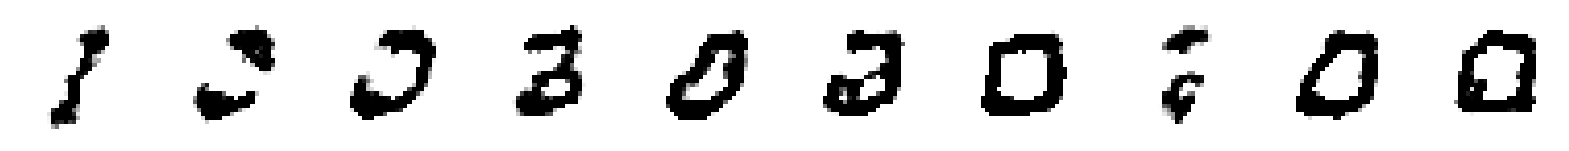


Saved to ./output/example_img_006.png


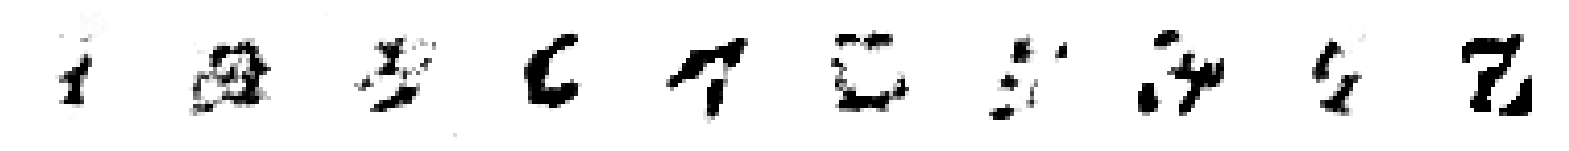

469/469 ━━━━━━━━━━━━━━━━━━━━ 315s 671ms/step - cdiv: -0.0041 - fake: -0.0025 - loss: -0.0026 - real: 0.0016 - reg: 0.0014 - val_cdiv: -14.7321 - val_fake: -14.6846 - val_real: 0.0474
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - cdiv: -0.0028 - fake: -0.0033 - loss: -0.0013 - real: -4.6357e-04 - reg: 0.0016
Saved to ./output/generated_img_007.png


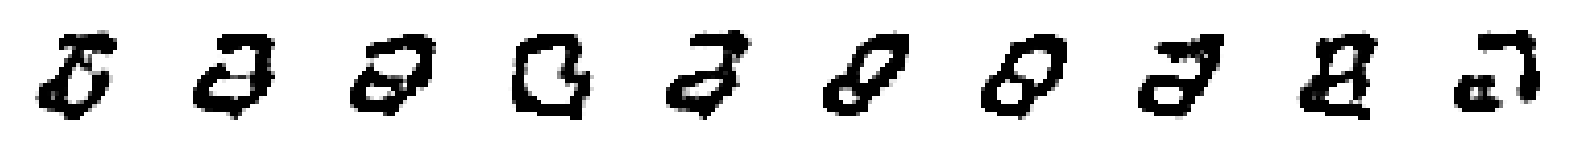


Saved to ./output/example_img_007.png


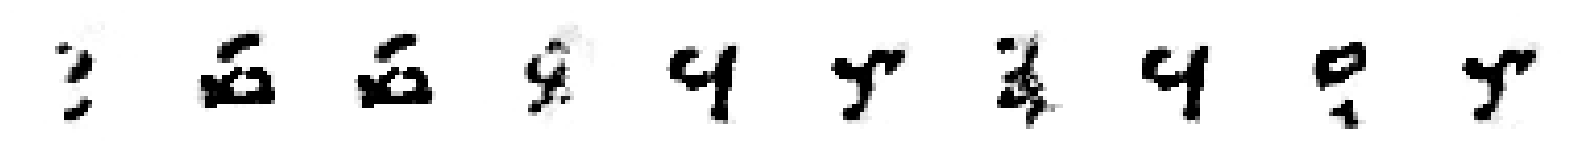

469/469 ━━━━━━━━━━━━━━━━━━━━ 317s 675ms/step - cdiv: -9.3869e-04 - fake: 4.4568e-04 - loss: 2.3079e-04 - real: 0.0014 - reg: 0.0012 - val_cdiv: -15.5444 - val_fake: -15.5222 - val_real: 0.0222
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - cdiv: -0.0055 - fake: -0.0063 - loss: -0.0040 - real: -8.1688e-04 - reg: 0.0014
Saved to ./output/generated_img_008.png


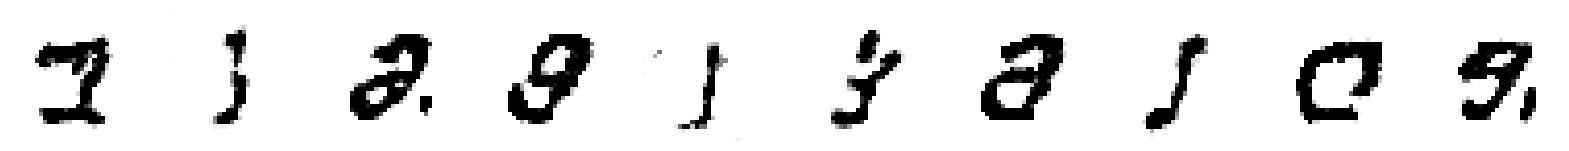


Saved to ./output/example_img_008.png


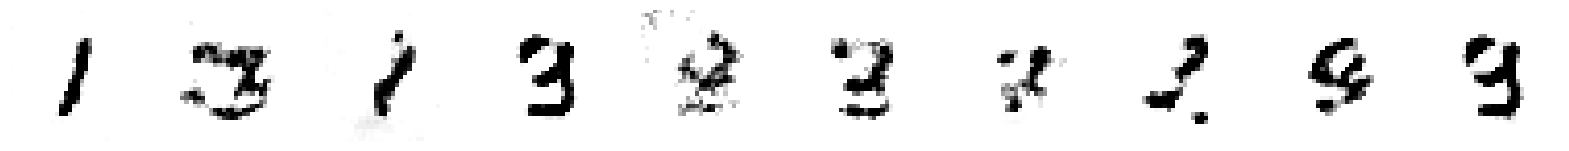

469/469 ━━━━━━━━━━━━━━━━━━━━ 316s 674ms/step - cdiv: -0.0030 - fake: -9.1539e-04 - loss: -0.0019 - real: 0.0021 - reg: 0.0012 - val_cdiv: -17.2610 - val_fake: -17.2313 - val_real: 0.0297
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - cdiv: -0.0033 - fake: -0.0034 - loss: -0.0020 - real: -9.3653e-05 - reg: 0.0012
Saved to ./output/generated_img_009.png


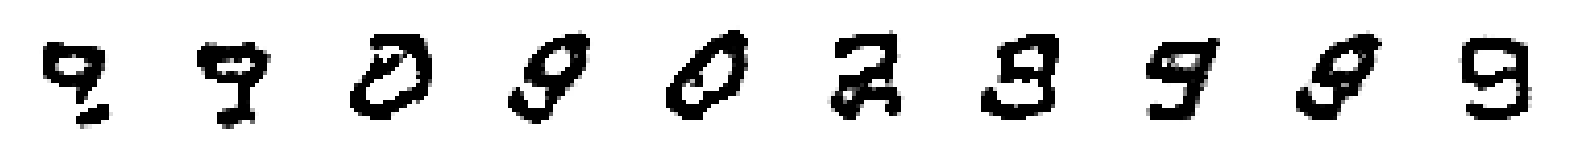


Saved to ./output/example_img_009.png


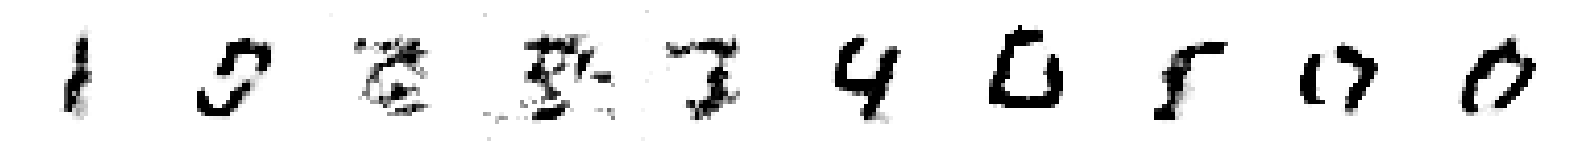

469/469 ━━━━━━━━━━━━━━━━━━━━ 314s 671ms/step - cdiv: -0.0022 - fake: -4.1847e-04 - loss: -0.0012 - real: 0.0018 - reg: 0.0010 - val_cdiv: -19.2610 - val_fake: -19.2333 - val_real: 0.0277


In [46]:
# Capture and plot the loss curve
history = ebm.fit(
    x_train,
    shuffle=True,
    epochs=EPOCHS,
    validation_data=x_test,
    callbacks=[
        save_model_callback,
        tensorboard_callback,
        image_generator_callback,
    ],
    # verbose=0,  # silent to avoid duplicate output
)

## 4. Generate images <a name="generate"></a>

In [47]:
start_imgs = (
    np.random.uniform(size=(10, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
)

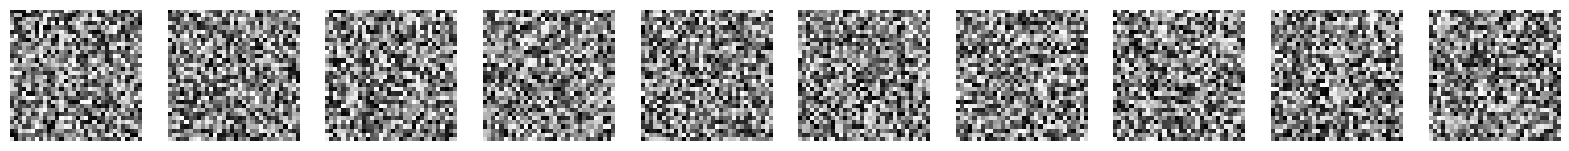

In [48]:
display(start_imgs)

In [49]:
gen_img = generate_samples(
    ebm.model,
    start_imgs,
    steps=1000,
    step_size=STEP_SIZE,
    noise=NOISE,
    return_img_per_step=True,
)

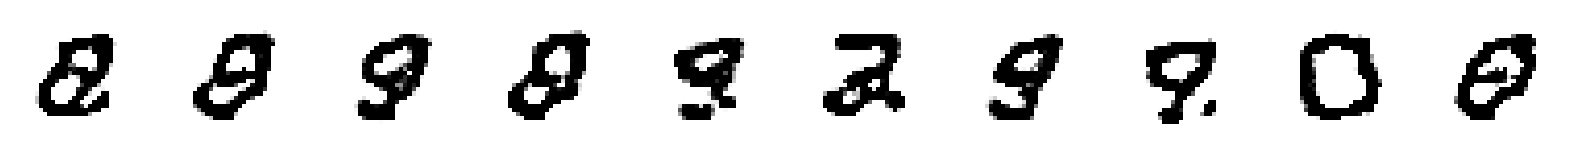

In [50]:
display(gen_img[-1].numpy())

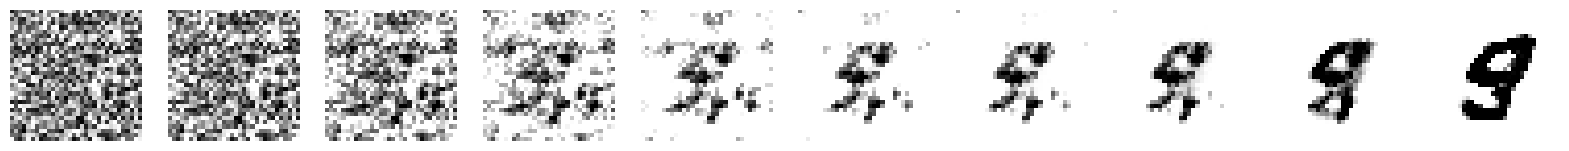

In [51]:
imgs = []
for i in [0, 1, 3, 5, 10, 30, 50, 100, 300, 999]:
    imgs.append(gen_img[i].numpy()[6])

display(np.array(imgs))

# Loss Table

In [52]:
history.history['loss'],

([-0.09168878942728043,
  -0.019323643296957016,
  -0.001676853746175766,
  -0.0031364180613309145,
  -0.0015403536381199956,
  -4.4385033106664196e-05,
  -0.0026457144413143396,
  0.00023078742378856987,
  -0.0018504898762330413,
  -0.0011856737546622753],)

In [53]:
import pandas as pd

# Create a DataFrame from the loss history
loss_df = pd.DataFrame({
    'Epoch': range(len(history.history['loss'])),
    'Loss': history.history['loss']
})

# Print the table
print(loss_df.to_string(index=False))

# Or for a prettier table with formatting:
print("\n" + "="*40)
print(f"{'Epoch':<10} {'Loss':<20}")
print("="*40)
for epoch, loss in enumerate(history.history['loss']):
    print(f"{epoch:<10} {loss:<20.6f}")
print("="*40)

 Epoch      Loss
     0 -0.091689
     1 -0.019324
     2 -0.001677
     3 -0.003136
     4 -0.001540
     5 -0.000044
     6 -0.002646
     7  0.000231
     8 -0.001850
     9 -0.001186

Epoch      Loss                
0          -0.091689           
1          -0.019324           
2          -0.001677           
3          -0.003136           
4          -0.001540           
5          -0.000044           
6          -0.002646           
7          0.000231            
8          -0.001850           
9          -0.001186           


# Loss Curve Plot

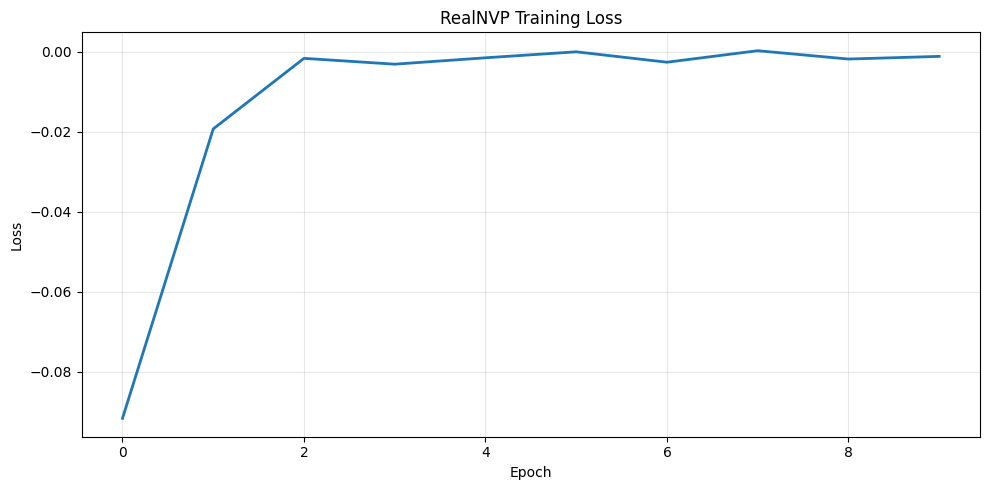

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RealNVP Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Loss Curves Comparison

**Key things to look for in your plots vs the reference:**

1. **`epoch_loss`** - Should decrease (yours may still be rising if training just started)
2. **`epoch_cdiv`** - Should decrease significantly (model learning to separate real/fake)
3. **`epoch_real`** - Should be stable around -0.05 to 0.05
4. **`epoch_fake`** - Should become increasingly negative (model pushing fake samples down)
5. **Real vs Fake divergence** - Gap should widen as training progresses

If your metrics aren't improving, check if you still have `run_eagerly=True` - switch it to `False` first!

In [56]:
history.history.keys()

dict_keys(['cdiv', 'fake', 'loss', 'real', 'reg', 'val_cdiv', 'val_fake', 'val_real'])

/tmp/ipykernel_52468/2158290128.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


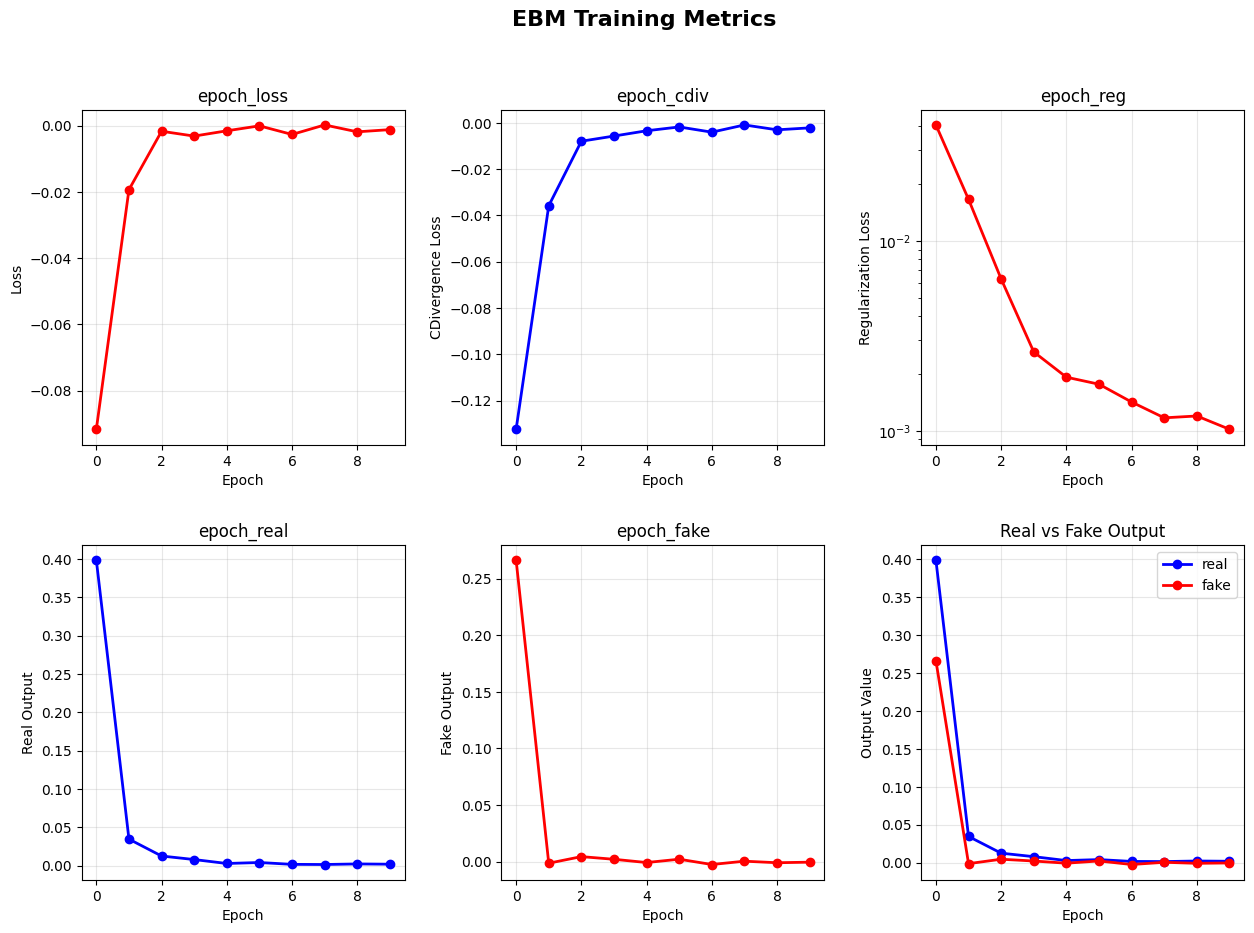

In [59]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure with 2x3 subplots matching the reference
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Extract history data
epochs = range(len(history.history['loss']))
loss = history.history['loss']
cdiv = history.history['cdiv']
reg = history.history['reg']
real_out = history.history['real']
fake_out = history.history['fake']

# Plot 1: epoch_loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, loss, 'o-', color='red', label='train', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('epoch_loss')
ax1.grid(True, alpha=0.3)

# Plot 2: epoch_cdiv
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, cdiv, 'o-', color='blue', label='train', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('CDivergence Loss')
ax2.set_title('epoch_cdiv')
ax2.grid(True, alpha=0.3)

# Plot 3: epoch_reg
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, reg, 'o-', color='red', label='train', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Regularization Loss')
ax3.set_title('epoch_reg')
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')

# Plot 4: epoch_real
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs, real_out, 'o-', color='blue', label='train', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Real Output')
ax4.set_title('epoch_real')
ax4.grid(True, alpha=0.3)

# Plot 5: epoch_fake
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(epochs, fake_out, 'o-', color='red', label='train', linewidth=2)
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Fake Output')
ax5.set_title('epoch_fake')
ax5.grid(True, alpha=0.3)

# Plot 6: Combined view
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(epochs, real_out, 'o-', color='blue', label='real', linewidth=2)
ax6.plot(epochs, fake_out, 'o-', color='red', label='fake', linewidth=2)
ax6.set_xlabel('Epoch')
ax6.set_ylabel('Output Value')
ax6.set_title('Real vs Fake Output')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('EBM Training Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Loss and Validation Loss Comparison

Improves analysis and matches expectations.

/tmp/ipykernel_52468/2261340044.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


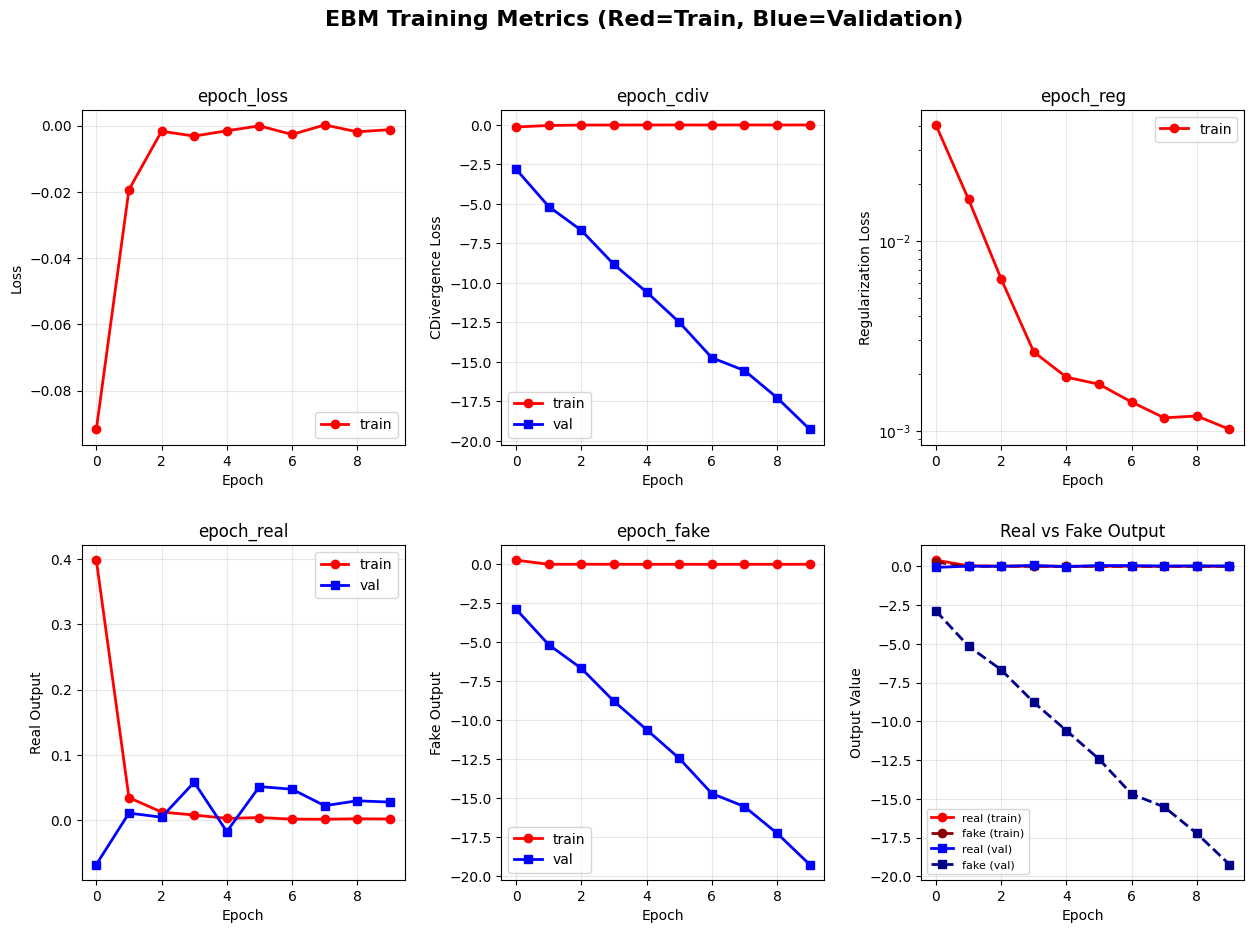

In [60]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure with 2x3 subplots matching the reference
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Extract history data
epochs = range(len(history.history['loss']))
loss = history.history['loss']
val_loss = history.history.get('val_loss', [])
cdiv = history.history['cdiv']
val_cdiv = history.history.get('val_cdiv', [])
reg = history.history['reg']
val_reg = history.history.get('val_reg', [])
real_out = history.history['real']
val_real_out = history.history.get('val_real', [])
fake_out = history.history['fake']
val_fake_out = history.history.get('val_fake', [])

# Plot 1: epoch_loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, loss, 'o-', color='red', label='train', linewidth=2)
if val_loss:
    ax1.plot(epochs, val_loss, 's-', color='blue', label='val', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('epoch_loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: epoch_cdiv
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, cdiv, 'o-', color='red', label='train', linewidth=2)
if val_cdiv:
    ax2.plot(epochs, val_cdiv, 's-', color='blue', label='val', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('CDivergence Loss')
ax2.set_title('epoch_cdiv')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: epoch_reg
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, reg, 'o-', color='red', label='train', linewidth=2)
if val_reg:
    ax3.plot(epochs, val_reg, 's-', color='blue', label='val', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Regularization Loss')
ax3.set_title('epoch_reg')
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')
ax3.legend()

# Plot 4: epoch_real
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs, real_out, 'o-', color='red', label='train', linewidth=2)
if val_real_out:
    ax4.plot(epochs, val_real_out, 's-', color='blue', label='val', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Real Output')
ax4.set_title('epoch_real')
ax4.grid(True, alpha=0.3)
ax4.legend()

# Plot 5: epoch_fake
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(epochs, fake_out, 'o-', color='red', label='train', linewidth=2)
if val_fake_out:
    ax5.plot(epochs, val_fake_out, 's-', color='blue', label='val', linewidth=2)
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Fake Output')
ax5.set_title('epoch_fake')
ax5.grid(True, alpha=0.3)
ax5.legend()

# Plot 6: Combined view (Real vs Fake)
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(epochs, real_out, 'o-', color='red', label='real (train)', linewidth=2)
ax6.plot(epochs, fake_out, 'o--', color='darkred', label='fake (train)', linewidth=2)
if val_real_out:
    ax6.plot(epochs, val_real_out, 's-', color='blue', label='real (val)', linewidth=2)
if val_fake_out:
    ax6.plot(epochs, val_fake_out, 's--', color='darkblue', label='fake (val)', linewidth=2)
ax6.set_xlabel('Epoch')
ax6.set_ylabel('Output Value')
ax6.set_title('Real vs Fake Output')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

plt.suptitle('EBM Training Metrics (Red=Train, Blue=Validation)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()